# 05.2 Model Comparison: Baseline vs PriceSequenceGRU vs HistGradientBoosting

Comparación reproducible entre los modelos actuales del repo usando los artefactos ya generados:
- `market_value_baseline`
- `price_sequence_gru`
- `hist_gradient_boosting`

El primario se elige por:
1. `top_k_avg_realized_pnl`
2. `brier`
3. `log_loss`
con la restricción de que debe superar al benchmark de mercado en al menos una métrica probabilística.


## 1. Setup

Cargamos raw data, checkpoints y pipeline del baseline. Si alguno de estos artefactos falta, la comparación todavía no está lista.

In [7]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.config import load_config

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

cfg = load_config(str(ROOT / 'config' / 'config.yaml'))
MODELS = ROOT / 'data' / 'models'
REGISTRY = MODELS / 'registry'
V1 = MODELS / 'v1'
V1_REGISTRY = V1 / 'registry'
comparison = json.loads((REGISTRY / 'model_comparison.json').read_text())
primary = json.loads((REGISTRY / 'primary_model.json').read_text())
live_summary = json.loads((REGISTRY / 'live_scoring_summary.json').read_text())
live_df = pd.read_csv(REGISTRY / 'live_scores.csv')
v1_comparison = json.loads((V1_REGISTRY / 'model_comparison.json').read_text()) if (V1_REGISTRY / 'model_comparison.json').exists() else None


## 2. Definición del universo común de evaluación

Primero leemos las métricas held-out guardadas por cada entrenamiento.
Después construimos un **universo común de diagnóstico** usando mercados que el TS sí puede secuenciar; eso no sustituye el test puro, pero sí permite comparar scores lado a lado.


In [8]:
rows = []
for model_name, payload in comparison['models'].items():
    test = payload['test']
    rows.append({
        'model_name': model_name,
        'beats_market': payload.get('beats_market'),
        'brier': test['calibrated_metrics']['brier'],
        'market_brier': test['market_baseline_metrics']['brier'],
        'log_loss': test['calibrated_metrics']['log_loss'],
        'market_log_loss': test['market_baseline_metrics']['log_loss'],
        'top_k_avg_realized_pnl': test['ev_metrics']['top_k_avg_realized_pnl'],
        'top_k_hit_rate': test['ev_metrics']['top_k_hit_rate'],
        'live_buy_signals': live_summary.get(model_name, {}).get('signals', {}).get('BUY', 0) + live_summary.get(model_name, {}).get('signals', {}).get('STRONG BUY', 0),
    })
summary_df = pd.DataFrame(rows).sort_values('top_k_avg_realized_pnl', ascending=False)
display(summary_df.round(4))


,model_name,beats_market,brier,market_brier,log_loss,market_log_loss,top_k_avg_realized_pnl,top_k_hit_rate,live_buy_signals
2,hist_gradient_boosting,True,0.0046,0.0062,0.0177,0.0221,0.2478,0.90,16
0,market_value_baseline,False,0.0111,0.0062,0.0462,0.0221,0.0267,0.15,42
1,price_sequence_gru,False,0.0269,0.0062,0.1287,0.0221,-0.0190,0.00,52


## 3. Carga de ambos modelos

Aquí no entrenamos nada: solo cargamos los checkpoints ya producidos por `04` y `04_1`.

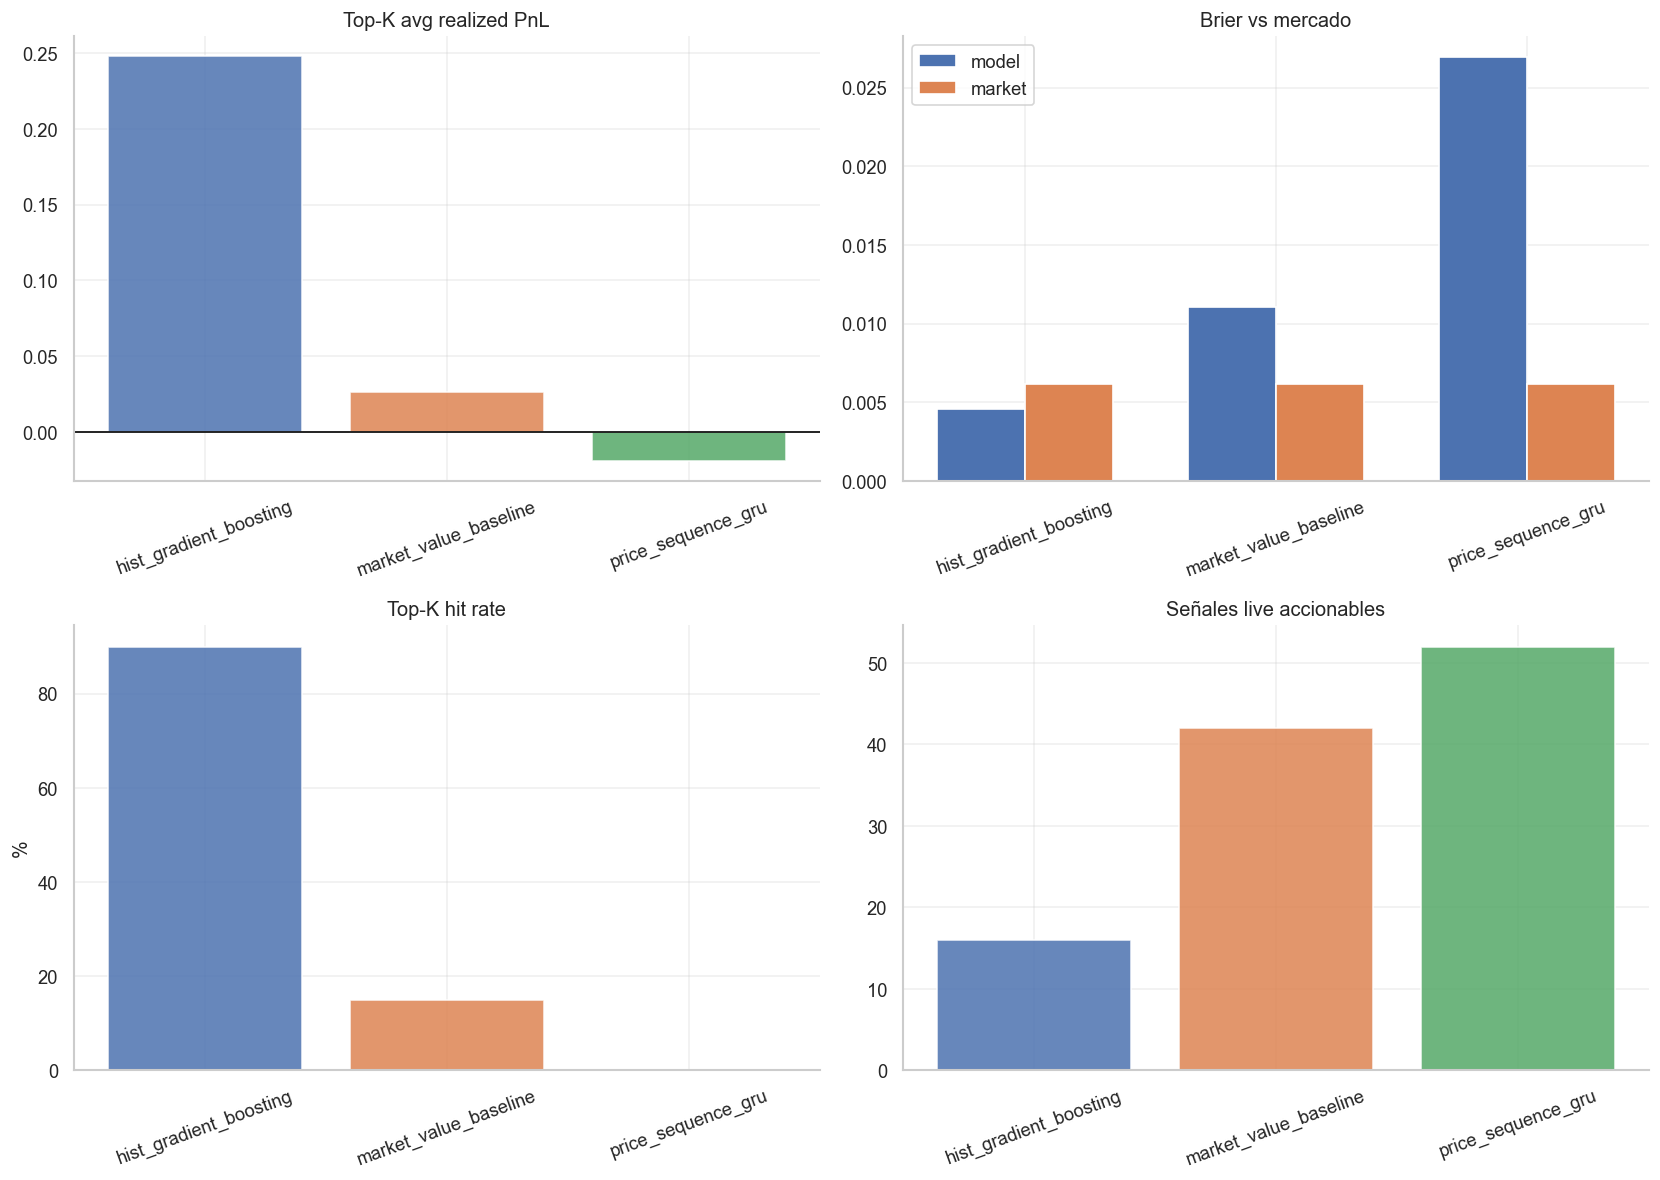

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.bar(summary_df['model_name'], summary_df['top_k_avg_realized_pnl'], color=PALETTE[:len(summary_df)], alpha=0.85)
ax.axhline(0, color='black', lw=1)
ax.set_title('Top-K avg realized PnL')
ax.tick_params(axis='x', rotation=20)

ax = axes[0, 1]
width = 0.35
x = np.arange(len(summary_df))
ax.bar(x - width/2, summary_df['brier'], width=width, color=PALETTE[0], label='model')
ax.bar(x + width/2, summary_df['market_brier'], width=width, color=PALETTE[1], label='market')
ax.set_xticks(x)
ax.set_xticklabels(summary_df['model_name'], rotation=20)
ax.set_title('Brier vs mercado')
ax.legend()

ax = axes[1, 0]
ax.bar(summary_df['model_name'], 100 * summary_df['top_k_hit_rate'], color=PALETTE[:len(summary_df)], alpha=0.85)
ax.set_title('Top-K hit rate')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=20)

ax = axes[1, 1]
ax.bar(summary_df['model_name'], summary_df['live_buy_signals'], color=PALETTE[:len(summary_df)], alpha=0.85)
ax.set_title('Señales live accionables')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## 4. Scoring del subconjunto temporal compartido

`PriceSequenceGRU` y `MarketValueNet` se evalúan sobre los mismos mercados resueltos y el mismo cutoff temporal. La intersección exacta es la base de la comparación offline.

In [10]:
bucket_rows = []
for model_name, payload in comparison['models'].items():
    for bucket_name, bucket_payload in payload['test'].get('by_horizon', {}).items():
        bucket_rows.append({
            'model_name': model_name,
            'bucket': bucket_name,
            'count': bucket_payload.get('count', 0),
            'brier': bucket_payload.get('probability_metrics', {}).get('brier'),
            'top_k_avg_realized_pnl': bucket_payload.get('ev_metrics', {}).get('top_k_avg_realized_pnl'),
            'top_k_hit_rate': bucket_payload.get('ev_metrics', {}).get('top_k_hit_rate'),
        })
bucket_df = pd.DataFrame(bucket_rows)
display(bucket_df.round(4))


,model_name,bucket,count,brier,top_k_avg_realized_pnl,top_k_hit_rate
0,market_value_baseline,short_1_3d,2380,0.0092,-0.0889,0.00
1,market_value_baseline,medium_4_14d,2380,0.0097,-0.0289,0.00
2,market_value_baseline,long_15plus,1167,0.0177,0.0438,0.15
3,price_sequence_gru,short_1_3d,2380,0.0243,-0.0368,0.00
4,price_sequence_gru,medium_4_14d,2380,0.0255,-0.0423,0.00
5,price_sequence_gru,long_15plus,1167,0.0352,-0.0490,0.00
6,hist_gradient_boosting,short_1_3d,2380,0.0036,0.0484,0.70
7,hist_gradient_boosting,medium_4_14d,2380,0.0034,0.0713,0.65
8,hist_gradient_boosting,long_15plus,1167,0.0089,0.2230,0.85


## 5. Métricas comparables en validación

Calculamos `AUC-ROC`, `PR-AUC` y `accuracy` para ambos modelos sobre la misma intersección de mercados válidos.

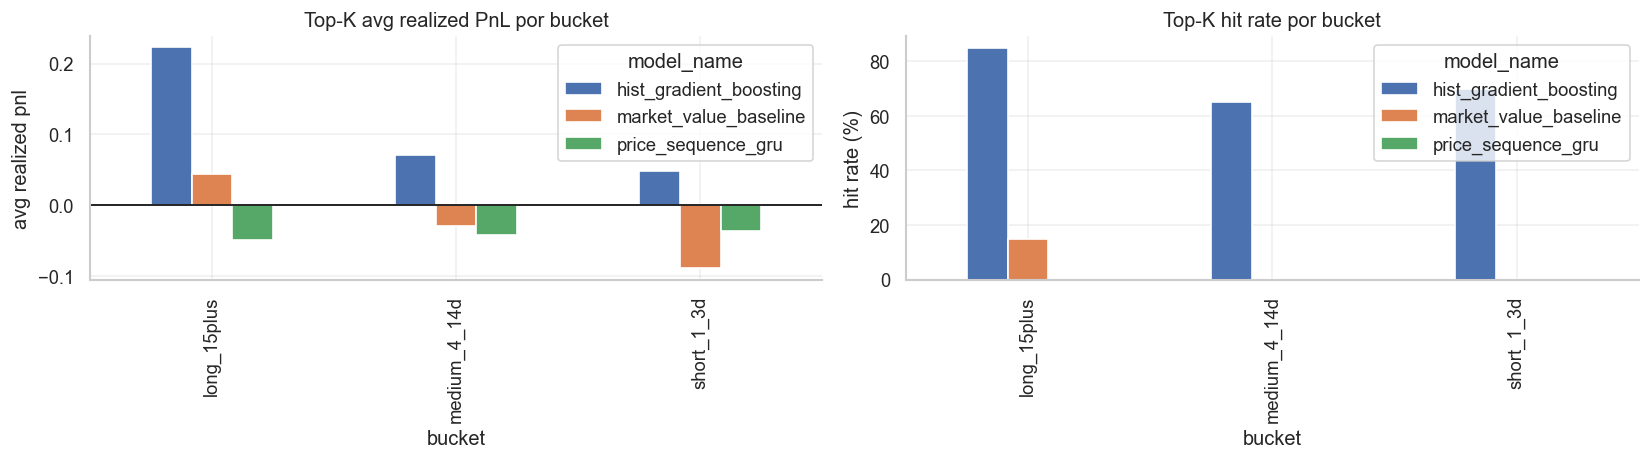

In [11]:
if not bucket_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    pivot = bucket_df.pivot(index='bucket', columns='model_name', values='top_k_avg_realized_pnl')
    pivot.plot.bar(ax=axes[0])
    axes[0].axhline(0, color='black', lw=1)
    axes[0].set_title('Top-K avg realized PnL por bucket')
    axes[0].set_ylabel('avg realized pnl')

    pivot_hit = bucket_df.pivot(index='bucket', columns='model_name', values='top_k_hit_rate')
    (100 * pivot_hit).plot.bar(ax=axes[1])
    axes[1].set_title('Top-K hit rate por bucket')
    axes[1].set_ylabel('hit rate (%)')
    plt.tight_layout()
    plt.show()


## 6. Lectura visual de desempeño offline

Este bloque ayuda a responder dos preguntas:
- cuál modelo se ve mejor en las métricas básicas
- cuánto se parecen realmente sus scores mercado por mercado

In [12]:
active_rows = []
for model_name in comparison['models'].keys():
    sub = live_df[live_df['model_name'] == model_name].copy()
    top = sub[sub['signal'] != 'HOLD'].copy().head(20)
    active_rows.append({
        'model_name': model_name,
        'signals': len(sub[sub['signal'] != 'HOLD']),
        'avg_ev_live': float(sub['ev_per_share'].mean()),
        'top20_avg_ev': float(top['ev_per_share'].mean()) if len(top) else np.nan,
    })
active_compare = pd.DataFrame(active_rows)
display(active_compare.round(4))


,model_name,signals,avg_ev_live,top20_avg_ev
0,market_value_baseline,42,0.2777,0.2421
1,price_sequence_gru,52,0.1021,0.2315
2,hist_gradient_boosting,16,-0.0140,0.1113


## 7. Comparación en mercados activos

Después de la comparación offline, llevamos ambos modelos al mismo snapshot local de activos y aplicamos las mismas reglas de señales. Eso permite medir overlap real de ideas operativas.

In [13]:
top_base = live_df[(live_df['model_name'] == 'market_value_baseline') & (live_df['signal'] != 'HOLD')][['id','question','ev_per_share','signal']].rename(columns={'ev_per_share':'ev_baseline','signal':'signal_baseline'})
top_ts = live_df[(live_df['model_name'] == 'price_sequence_gru') & (live_df['signal'] != 'HOLD')][['id','ev_per_share','signal']].rename(columns={'ev_per_share':'ev_ts','signal':'signal_ts'})
top_gbdt = live_df[(live_df['model_name'] == 'hist_gradient_boosting') & (live_df['signal'] != 'HOLD')][['id','ev_per_share','signal']].rename(columns={'ev_per_share':'ev_gbdt','signal':'signal_gbdt'})

disagreements = top_base.merge(top_ts, on='id', how='outer').merge(top_gbdt, on='id', how='outer').merge(
    live_df[['id','question']].drop_duplicates(), on='id', how='left'
)
display(disagreements.head(20))


,id,question_x,ev_baseline,signal_baseline,ev_ts,signal_ts,ev_gbdt,signal_gbdt,question_y
0,951183,Will the Bharatiya Janata Party (BJP) win the ...,0.207759,STRONG BUY,0.134091,STRONG BUY,0.046233,BUY,Will the Bharatiya Janata Party (BJP) win the ...
1,1363116,"Will Claude 5 be released by April 30, 2026?",0.174114,STRONG BUY,0.216917,STRONG BUY,NaN,NaN,"Will Claude 5 be released by April 30, 2026?"
2,1507751,NaN,NaN,NaN,0.236628,STRONG BUY,NaN,NaN,Will the Iranian regime fall by April 30?
3,1517835,Trump announces end of military operations aga...,0.167759,STRONG BUY,0.174796,STRONG BUY,NaN,NaN,Trump announces end of military operations aga...
4,1535972,Iran leadership change by April 30?,0.174268,STRONG BUY,0.216917,STRONG BUY,NaN,NaN,Iran leadership change by April 30?
5,1540766,Strait of Hormuz traffic returns to normal by ...,0.211812,STRONG BUY,0.216917,STRONG BUY,NaN,NaN,Strait of Hormuz traffic returns to normal by ...
6,1540956,Will María Corina Machado enter Venezuela by A...,0.249432,STRONG BUY,0.216917,STRONG BUY,NaN,NaN,Will María Corina Machado enter Venezuela by A...
7,1543487,US-Iran nuclear deal by April 30?,0.254826,STRONG BUY,0.225628,STRONG BUY,NaN,NaN,US-Iran nuclear deal by April 30?
8,1567746,Iran x Israel/US conflict ends by April 15?,0.247636,STRONG BUY,0.217112,STRONG BUY,NaN,NaN,Iran x Israel/US conflict ends by April 15?
9,1567747,Iran x Israel/US conflict ends by April 30?,0.263247,STRONG BUY,0.196917,STRONG BUY,NaN,NaN,Iran x Israel/US conflict ends by April 30?


## 8. Overlap y desacuerdos más fuertes

La parte más útil de esta sección no es solo el overlap, sino los mercados donde ambos modelos discrepan mucho. Ahí suele estar la señal nueva del modelo secuencial.

In [14]:
print('Modelo primario actual:')
display(pd.Series(primary))
print('\nLectura rápida:')
print('- Si un modelo no mejora a mercado en Brier o log_loss, no debería ser primario.')
print('- Hoy el GBDT es el único que gana simultáneamente en calibración y utilidad económica.')
print('- Las redes quedan más útiles como modelos secundarios de ranking/diagnóstico.')


Modelo primario actual:


name                                           hist_gradient_boosting
save_dir                           data/models/hist_gradient_boosting
selection_metric    eligible_if(top_k_pnl>0 and beats_market_prob)...
dtype: str


Lectura rápida:
- Si un modelo no mejora a mercado en Brier o log_loss, no debería ser primario.
- Hoy el GBDT es el único que gana simultáneamente en calibración y utilidad económica.
- Las redes quedan más útiles como modelos secundarios de ranking/diagnóstico.


## 9. Cómo interpretar el resultado final

Al cerrar este notebook, una lectura útil es:
- si el GRU mejora métricas offline o no
- si propone mercados distintos al baseline en activos
- si las discrepancias parecen razonables según la trayectoria del precio

Si ambos modelos aportan algo distinto, ya tienes base para explorar ensemble o reglas de consenso más adelante.